# Exploratory Data Analysis: NYC Taxi Trips
This notebook presents a structured exploratory data analysis (EDA) of NYC taxi trip data. The goal is to examine spatial, temporal, and behavioral patterns in taxi usage, with a focus on fares, tipping behavior, payment methods, and pickup/dropoff dynamics.


In [3]:
# from google.colab import drive


# drive.mount('/content/drive')


## Data Preparation
Datetime fields are converted into timestamp objects to support temporal analysis. Derived features such as hour of day and normalized cost metrics are created to enable comparative analysis. Data cleaning is limited to filtering invalid or zero-distance trips.


This cell loads the NYC taxi trip dataset and any associated lookup tables into pandas DataFrames. These DataFrames serve as the foundation for all subsequent exploratory analysis.



In [ ]:
import pandas as pd
import numpy as np

# 1 min 30 sec is typical load time currently
# 6 min 00 sec is typical load after datetime filter was applied

path = '2023_Yellow_Taxi_Trip_Data.csv'

dt_format = "%m/%d/%Y %I:%M:%S %p"

taxi_dataset = pd.read_csv(
    path,
    parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"],
    date_format=dt_format,     # speeds up a lot vs inference
    engine="c",                # default, fast
)


/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_5455/2515098855.py:13: DtypeWarning: Columns (4,6,10,11,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  taxi_dataset = pd.read_csv(


## Dataset Description
The dataset contains individual taxi trip records from New York City. Each observation represents a single trip and includes temporal information, pickup and dropoff locations, fare components, passenger counts, and payment type. Location identifiers are encoded numerically and later mapped to human-readable zone and borough names using the official NYC Taxi Zone lookup table.


In [ ]:
taxi_dataset.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.1,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.9,1.0,N,138,7,1,12.1,7.25,0.5,0.0,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.0,0.5,3.28,0.0,1.0,19.68,2.5,0.00


This cell performs a targeted aggregation or visualization step that advances the exploratory analysis

In [ ]:
print(f"LISTED FEATURES:\n{taxi_dataset.loc[0]}")

LISTED FEATURES:
VendorID                                   2
tpep_pickup_datetime     2023-01-01 00:32:10
tpep_dropoff_datetime    2023-01-01 00:40:36
passenger_count                          1.0
trip_distance                           0.97
RatecodeID                               1.0
store_and_fwd_flag                         N
PULocationID                             161
DOLocationID                             141
payment_type                               2
fare_amount                              9.3
extra                                    1.0
mta_tax                                  0.5
tip_amount                               0.0
tolls_amount                             0.0
improvement_surcharge                    1.0
total_amount                            14.3
congestion_surcharge                     2.5
airport_fee                              0.0
Name: 0, dtype: object


In [ ]:
for i in range(50):
  print(taxi_dataset.loc[i])

VendorID                                   2
tpep_pickup_datetime     2023-01-01 00:32:10
tpep_dropoff_datetime    2023-01-01 00:40:36
passenger_count                          1.0
trip_distance                           0.97
RatecodeID                               1.0
store_and_fwd_flag                         N
PULocationID                             161
DOLocationID                             141
payment_type                               2
fare_amount                              9.3
extra                                    1.0
mta_tax                                  0.5
tip_amount                               0.0
tolls_amount                             0.0
improvement_surcharge                    1.0
total_amount                            14.3
congestion_surcharge                     2.5
airport_fee                              0.0
Name: 0, dtype: object
VendorID                                   2
tpep_pickup_datetime     2023-01-01 00:55:08
tpep_dropoff_datetime    2023-01

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

df = taxi_dataset

df["tpep_pickup_datetime"] = pd.to_datetime(
    taxi_dataset["tpep_pickup_datetime"], errors="coerce"
)

df["tpep_dropoff_datetime"] = pd.to_datetime(
    taxi_dataset["tpep_dropoff_datetime"], errors="coerce"
)


df["pickup_hour"] = taxi_dataset["tpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = taxi_dataset["tpep_pickup_datetime"].dt.dayofweek

numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "congestion_surcharge",
    "airport_fee"
]

df[numeric_cols] = taxi_dataset[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

df.groupby("pickup_hour")["tip_amount"].mean()

pickup_counts = taxi_dataset["PULocationID"].value_counts().head(10)
dropoff_counts = taxi_dataset["DOLocationID"].value_counts().head(10)

df.groupby("PULocationID")["fare_amount"].mean().sort_values(ascending=False).head(10)

paymenttype = {0 : 'Flex Fare trip', 1 : 'Credit card', 2 : 'Cash', 3 : 'No charge', 4 : 'Dispute', 5 : 'Unknown', 6 : 'Voided trip'}

df["payment_type_label"] = df["payment_type"].map(paymenttype)

df.groupby("payment_type")["fare_amount"].mean()


df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38310226 entries, 0 to 38310225
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee         

<Figure size 1000x600 with 0 Axes>

In [ ]:
import pandas as pd

vendorid = {1 : "Creative Mobile Technologies, LLC", 2 : "Curb Mobility, LLC", 6 : "Myle Technologies Inc", 7 : "Helix"}

ratecodeid = {1 : 'Standard rate', 2 : 'JFK', 3 : 'Newark', 4 : 'Nassau or Westchester', 5 : 'Negotiated fare', 6 : 'Group ride', 99 : 'Null/unknown'}

taxizonelookup = pd.read_csv('/content/drive/My Drive/DSCI 591/taxi_zone_lookup.csv')
tzl_features = ["LocationID", "Borough", "Zone service_zone"]

taxizonelookup

print(taxizonelookup)

bug = "AI at it's core is just the machine portion when running a probability machine because data scientists can harness this power = Sam Porter Bridges (not really)"

     LocationID        Borough                     Zone service_zone
0             1            EWR           Newark Airport          EWR
1             2         Queens              Jamaica Bay    Boro Zone
2             3          Bronx  Allerton/Pelham Gardens    Boro Zone
3             4      Manhattan            Alphabet City  Yellow Zone
4             5  Staten Island            Arden Heights    Boro Zone
..          ...            ...                      ...          ...
260         261      Manhattan       World Trade Center  Yellow Zone
261         262      Manhattan           Yorkville East  Yellow Zone
262         263      Manhattan           Yorkville West  Yellow Zone
263         264        Unknown                      NaN          NaN
264         265            NaN           Outside of NYC          NaN

[265 rows x 4 columns]


In [ ]:
# Taxi Zone lookup (LocationID -> Borough – Zone)
# NOTE: Update the path if needed, e.g.:
# zones = pd.read_csv('/content/drive/MyDrive/<your-folder>/taxi_zone_lookup.csv')
try:
    zones = pd.read_csv('/content/drive/MyDrive/DSCI 591/taxi_zone_lookup.csv')
    location_dict = dict(
        zip(
            zones["LocationID"],
            zones["Borough"].astype(str) + " – " + zones["Zone"].astype(str)
        )
    )
except FileNotFoundError as e:
    print("Couldn't find 'taxi_zone_lookup.csv'. Upload it to your runtime or update the path above.")
    raise


## Temporal Patterns
This section explores how taxi activity and fare behavior vary across different times of day. Aggregations are performed using pickup timestamps to identify daily usage cycles and associated tipping trends.


/tmp/ipython-input-145787338.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['distance_bin', 'time_of_day'])['tip_amount']


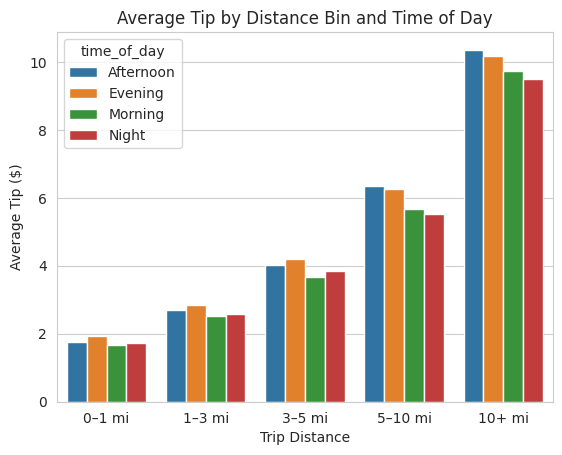

In [ ]:
# time-of-day feature
try:
  df['pickup_datetime'] = pd.to_datetime(['pickup_datetime'])
except:
  bug = "squashed"

#df['hour'] = df['pickup_datetime'].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['pickup_hour'].apply(time_of_day)

# control for “same trip' using distance bins
df['distance_bin'] = pd.cut(
    df['trip_distance'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['0–1 mi', '1–3 mi', '3–5 mi', '5–10 mi', '10+ mi']
)

# tips by time of day (normalized by distance)
tip_analysis = (
    df.groupby(['distance_bin', 'time_of_day'])['tip_amount']
      .mean()
      .reset_index()
)

sns.barplot(
    data=tip_analysis,
    x='distance_bin',
    y='tip_amount',
    hue='time_of_day'
)

plt.title('Average Tip by Distance Bin and Time of Day')
plt.xlabel('Trip Distance')
plt.ylabel('Average Tip ($)')
plt.show()



## Spatial Distribution of Trips
Pickup and dropoff locations are analyzed using trip frequency and average fare metrics. Numeric location identifiers are mapped to descriptive zone labels to improve interpretability. Visualizations focus on the most frequently used locations to avoid noise from sparse zones.


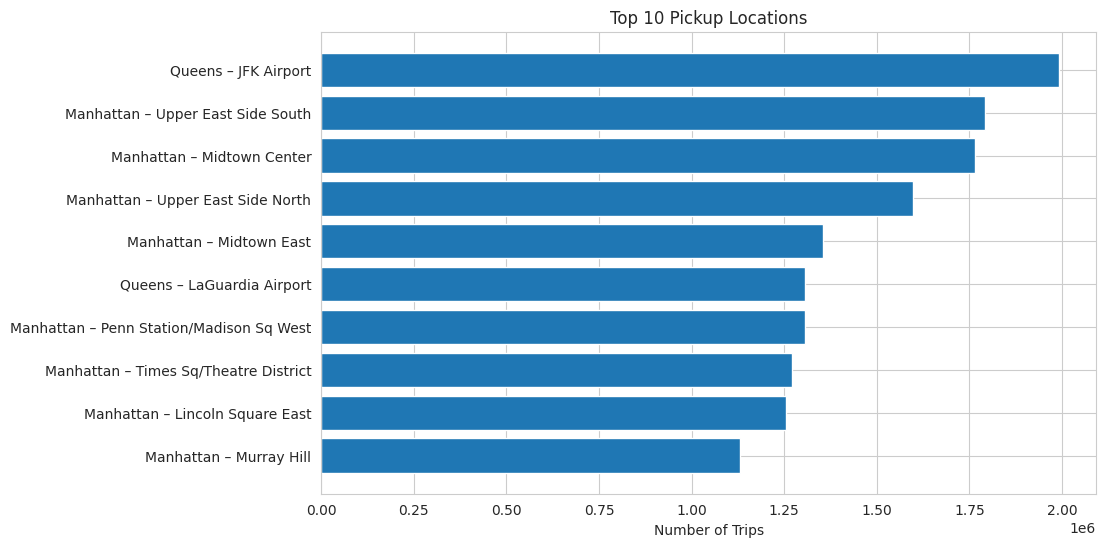

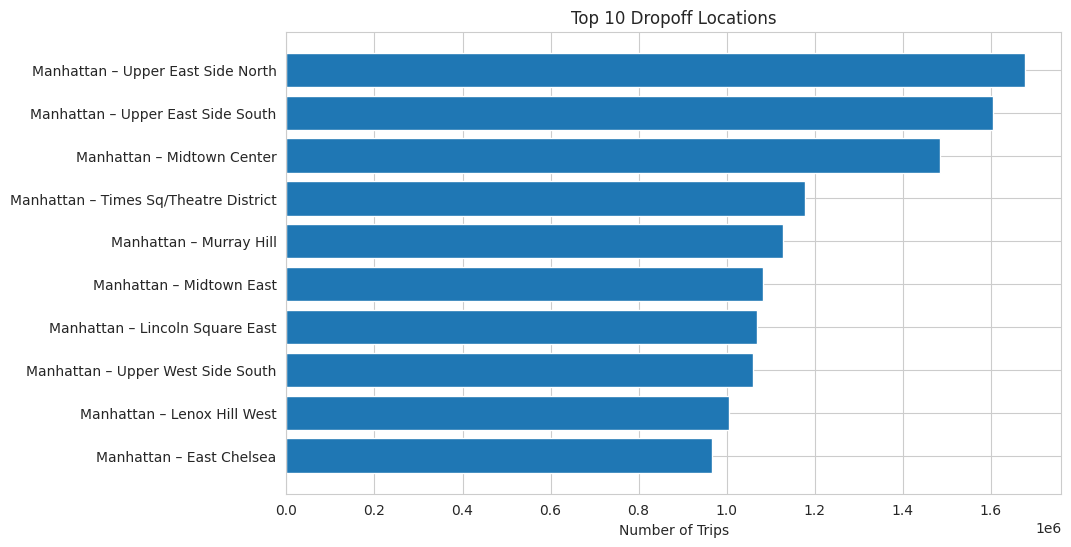

In [ ]:
# Pickup & dropoff frequency (Top 10) with human-readable zone labels
pickup_counts = (
    df["PULocationID"]
      .value_counts()
      .head(10)
      .reset_index()
)
pickup_counts.columns = ["PULocationID", "trip_count"]
pickup_counts["pickup_zone"] = pickup_counts["PULocationID"].map(location_dict)

dropoff_counts = (
    df["DOLocationID"]
      .value_counts()
      .head(10)
      .reset_index()
)
dropoff_counts.columns = ["DOLocationID", "trip_count"]
dropoff_counts["dropoff_zone"] = dropoff_counts["DOLocationID"].map(location_dict)

# Plot: Top pickup locations
plt.figure(figsize=(10, 6))
plt.barh(pickup_counts["pickup_zone"], pickup_counts["trip_count"])
plt.xlabel("Number of Trips")
plt.title("Top 10 Pickup Locations")
plt.gca().invert_yaxis()
plt.show()

# Plot: Top dropoff locations
plt.figure(figsize=(10, 6))
plt.barh(dropoff_counts["dropoff_zone"], dropoff_counts["trip_count"])
plt.xlabel("Number of Trips")
plt.title("Top 10 Dropoff Locations")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
df['distance_bin'] = pd.cut(
    df['trip_distance'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['0–1 mi', '1–3 mi', '3–5 mi', '5–10 mi', '10+ mi']
)



## Fare and Tip Analysis
Fare-related variables are examined both in absolute terms and normalized by trip distance. This allows for identification of congestion effects, short-trip pricing behavior, and differences in tipping generosity across trip contexts.


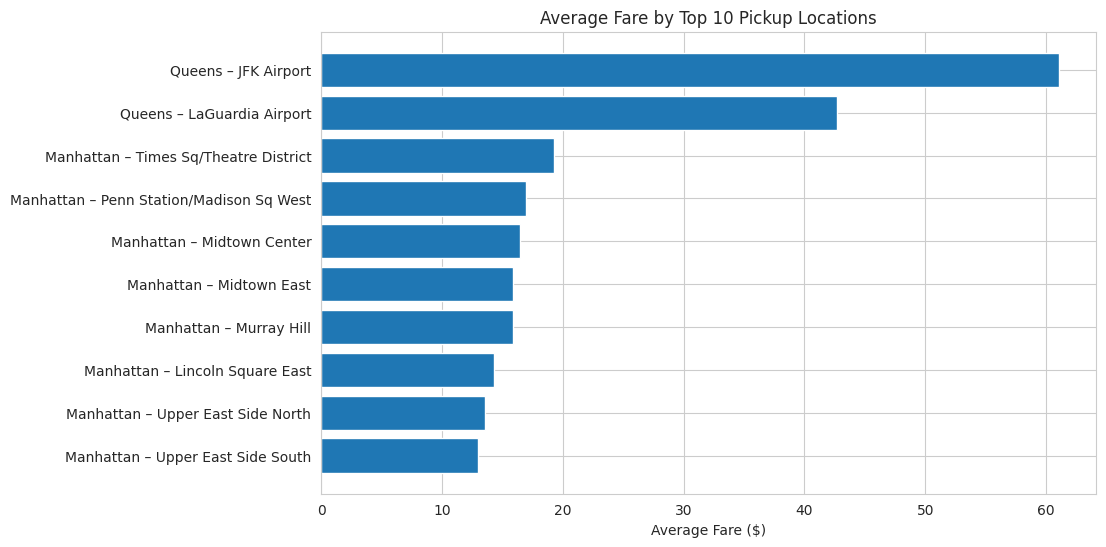

,pickup_zone,dropoff_zone,fare_amount
26580,Queens – Middle Village,nan – Outside of NYC,336.20
16596,Staten Island – Freshkills Park,nan – Outside of NYC,298.05
8629,Brooklyn – Coney Island,EWR – Newark Airport,280.00
13831,Staten Island – Eltingville/Annadale/Prince's Bay,Queens – LaGuardia Airport,269.00
18,EWR – Newark Airport,Brooklyn – East New York,258.50
29933,Queens – Ozone Park,Brooklyn – Canarsie,250.00
13105,Brooklyn – East Williamsburg,Bronx – Bronxdale,242.75
24939,Brooklyn – Manhattan Beach,EWR – Newark Airport,229.25
6773,Staten Island – Charleston/Tottenville,Queens – Flushing,224.20
29384,Queens – Oakland Gardens,Queens – Saint Michaels Cemetery/Woodside,221.40


In [ ]:
# Average fare by pickup location (using the same Top 10 pickup zones)
# If you'd rather use total_amount instead of fare_amount, swap the column below.
avg_fare_pickup = (
    df[df["PULocationID"].isin(pickup_counts["PULocationID"])]
      .groupby("PULocationID")["fare_amount"]
      .mean()
      .reset_index()
)

# Bring in trip_count so you can sort/filter consistently with "most frequent" zones
avg_fare_pickup = avg_fare_pickup.merge(
    pickup_counts[["PULocationID", "trip_count"]],
    on="PULocationID",
    how="left"
)

# Map LocationID → readable label (do this AFTER the merge to avoid *_x / *_y columns)
avg_fare_pickup["pickup_zone"] = avg_fare_pickup["PULocationID"].map(location_dict)

# Sort so the bar chart reads nicely (lowest at top, highest at bottom)
avg_fare_pickup = avg_fare_pickup.sort_values("fare_amount", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(avg_fare_pickup["pickup_zone"], avg_fare_pickup["fare_amount"])
plt.xlabel("Average Fare ($)")
plt.title("Average Fare by Top 10 Pickup Locations")
plt.show()

# Pickup → dropoff interaction (Top 10 most expensive average pairs)
pair_fares = (
    df.groupby(["PULocationID", "DOLocationID"])["fare_amount"]
      .mean()
      .reset_index()
      .sort_values(by="fare_amount", ascending=False)
      .head(10)
)

pair_fares["pickup_zone"] = pair_fares["PULocationID"].map(location_dict)
pair_fares["dropoff_zone"] = pair_fares["DOLocationID"].map(location_dict)

pair_fares[["pickup_zone", "dropoff_zone", "fare_amount"]]


## Payment Method Behavior
Trips are grouped by payment method to compare fare and tipping behavior. Payment type codes are translated into descriptive labels to ensure clarity in analysis and visualizations.


Index(['payment_type', 'total_amount'], dtype='object')


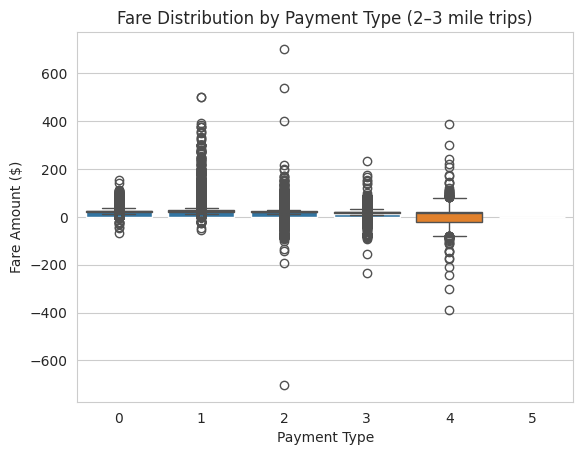

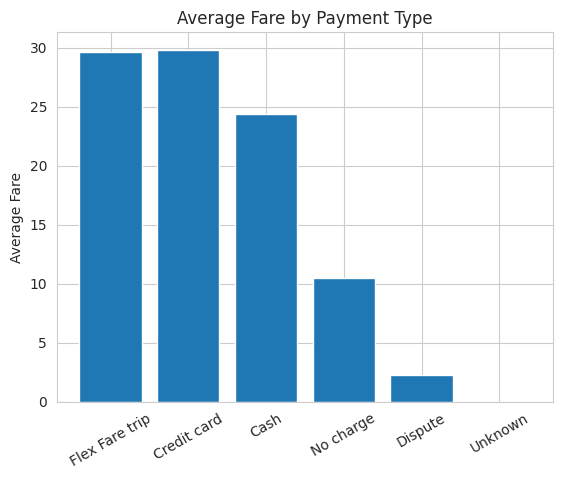

In [ ]:
# filter to comparable trips
filtered_df = df[
    (df['trip_distance'] >= 2) &
    (df['trip_distance'] <= 3)
]


# fare comparison by payment type
payment_fares = (
    df.groupby("payment_type")["total_amount"]
      .mean()
      .reset_index()
)

print(payment_fares.columns)


payment_fares["payment_label"] = payment_fares["payment_type"].map(paymenttype)


sns.barplot(
    data=payment_fares,
    x='payment_type',
    y='total_amount'
)



# distribution view
sns.boxplot(
    data=filtered_df,
    x='payment_type',
    y='total_amount'
)

plt.title('Fare Distribution by Payment Type (2–3 mile trips)')
plt.xlabel('Payment Type')
plt.ylabel('Fare Amount ($)')
plt.show()

plt.bar(payment_fares["payment_label"], payment_fares["total_amount"])
plt.xticks(rotation=30)
plt.ylabel("Average Fare")
plt.title("Average Fare by Payment Type")
plt.show()




## Extended Analysis
Additional analyses are conducted based on insights from earlier sections, including pickup versus dropoff imbalances, fare variability by location, and airport versus non-airport trip comparisons.


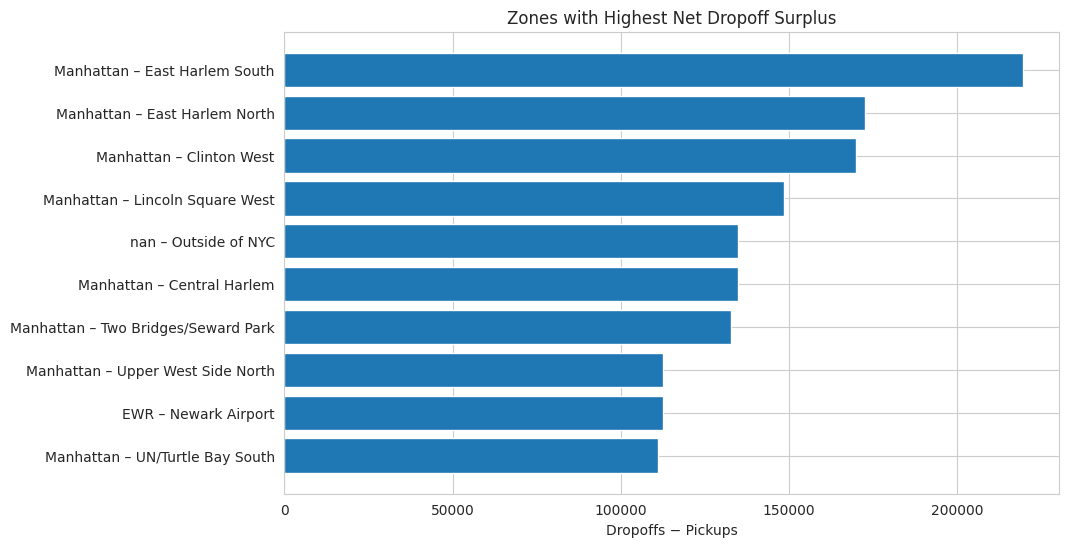

In [ ]:
pickup_counts = df["PULocationID"].value_counts()
dropoff_counts = df["DOLocationID"].value_counts()

flow_balance = pd.DataFrame({
    "pickups": pickup_counts,
    "dropoffs": dropoff_counts
}).fillna(0)

flow_balance["net_flow"] = flow_balance["dropoffs"] - flow_balance["pickups"]
flow_balance["zone"] = flow_balance.index.map(location_dict)

top_net_flow = flow_balance.sort_values("net_flow", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_net_flow["zone"], top_net_flow["net_flow"])
plt.title("Zones with Highest Net Dropoff Surplus")
plt.xlabel("Dropoffs − Pickups")
plt.gca().invert_yaxis()
plt.show()


Here, I construct a mapping between the numeric location identifiers used in the dataset and their corresponding borough and zone names. This translation step is critical for making later spatial analyses interpretable rather than relying on opaque numeric codes.

In [ ]:
#Do the busiest pickup zones change by time of day?

df["hour"] = df["tpep_pickup_datetime"].dt.hour

time_zone = (
    df.groupby(["hour", "PULocationID"])
      .size()
      .reset_index(name="trip_count")
)

time_zone["zone"] = time_zone["PULocationID"].map(location_dict)

top_time_zone = (
    time_zone.sort_values("trip_count", ascending=False)
             .groupby("hour")
             .head(1)
)

top_time_zone[["hour", "zone", "trip_count"]]


,hour,zone,trip_count
4696,18,Manhattan – Midtown Center,154215
4444,17,Manhattan – Midtown Center,149629
4158,16,Queens – JFK Airport,140615
5681,22,Queens – JFK Airport,138845
3748,14,Manhattan – Upper East Side South,137157
4004,15,Manhattan – Upper East Side South,136673
4951,19,Manhattan – Midtown Center,134987
5433,21,Queens – JFK Airport,130421
5179,20,Queens – JFK Airport,129554
5937,23,Queens – JFK Airport,128129


Here, I construct a mapping between the numeric location identifiers used in the dataset and their corresponding borough and zone names. This translation step is critical for making later spatial analyses interpretable rather than relying on opaque numeric codes.

/tmp/ipython-input-313343225.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]


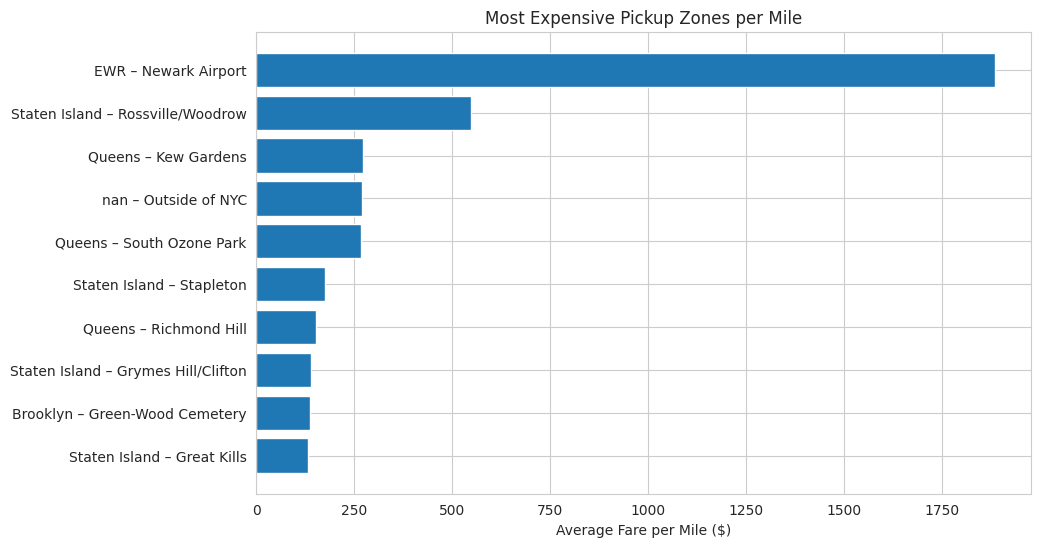

In [ ]:
#Detects congestion pricing effects
#Reveals short expensive trips
#Strong analytical signal

df = df[df["trip_distance"] > 0]

df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]

fare_efficiency = (
    df.groupby("PULocationID")["fare_per_mile"]
      .mean()
      .reset_index()
)

fare_efficiency["zone"] = fare_efficiency["PULocationID"].map(location_dict)

top_expensive_mile = fare_efficiency.sort_values(
    "fare_per_mile", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_expensive_mile["zone"], top_expensive_mile["fare_per_mile"])
plt.xlabel("Average Fare per Mile ($)")
plt.title("Most Expensive Pickup Zones per Mile")
plt.gca().invert_yaxis()
plt.show()


This cell aggregates trips by payment method and computes summary statistics such as average fares or tips. The goal is to understand how passenger payment choices correlate with spending and tipping behavior.

/tmp/ipython-input-3682618789.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tip_per_mile"] = df["tip_amount"] / df["trip_distance"]


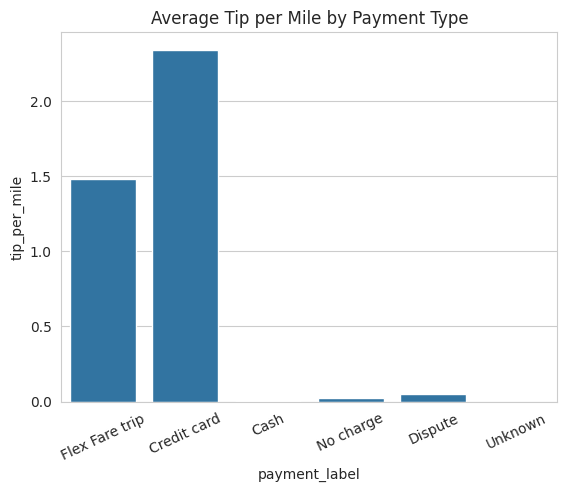

In [ ]:
#Are passengers tipping more generously, or just taking longer trips?

df["tip_per_mile"] = df["tip_amount"] / df["trip_distance"]

tip_efficiency = (
    df[df["trip_distance"] > 0]
    .groupby("payment_type")["tip_per_mile"]
    .mean()
    .reset_index()
)

tip_efficiency["payment_label"] = tip_efficiency["payment_type"].map(paymenttype)

sns.barplot(
    data=tip_efficiency,
    x="payment_label",
    y="tip_per_mile"
)
plt.xticks(rotation=25)
plt.title("Average Tip per Mile by Payment Type")
plt.show()


Here, I distinguish airport trips from non-airport trips using the airport fee indicator. This enables a direct comparison of fare, distance, and tipping patterns between airport-related travel and typical city trips.

In [ ]:
#Airport vs non-airport trip behavior

df["airport_trip"] = df["airport_fee"] > 0

airport_summary = (
    df.groupby("airport_trip")[["fare_amount", "trip_distance", "tip_amount"]]
      .mean()
      .reset_index()
)

airport_summary["trip_type"] = airport_summary["airport_trip"].map({
    True: "Airport Trip",
    False: "Non-Airport Trip"
})

airport_summary


/tmp/ipython-input-2543279108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["airport_trip"] = df["airport_fee"] > 0


,airport_trip,fare_amount,trip_distance,tip_amount,trip_type
0,False,16.122734,2.614492,3.061489,Non-Airport Trip
1,True,54.824529,13.315713,8.857233,Airport Trip


Here, I construct a mapping between the numeric location identifiers used in the dataset and their corresponding borough and zone names. This translation step is critical for making later spatial analyses interpretable rather than relying on opaque numeric codes.

In [ ]:
fare_variability = (
    df.groupby("PULocationID")["total_amount"]
      .agg(["mean", "std"])
      .reset_index()
)

fare_variability["zone"] = fare_variability["PULocationID"].map(location_dict)

high_variance = fare_variability.sort_values("std", ascending=False).head(10)

high_variance[["zone", "mean", "std"]]


,zone,mean,std
153,Staten Island – Mariners Harbor,62.217368,132.799126
98,Staten Island – Freshkills Park,68.223846,129.497727
248,Staten Island – Westerleigh,112.107586,128.108247
112,Staten Island – Grymes Hill/Clifton,65.199375,106.467365
218,Staten Island – Stapleton,63.915476,106.250144
181,Bronx – Pelham Bay Park,70.337377,92.776679
83,Staten Island – Eltingville/Annadale/Prince's Bay,91.335556,87.698329
0,EWR – Newark Airport,96.548187,64.236605
216,Queens – Springfield Gardens South,70.551779,63.006721
151,Brooklyn – Marine Park/Floyd Bennett Field,42.887609,62.607068


## Summary
The analysis reveals strong spatial and temporal structure in NYC taxi trips. Certain zones function primarily as origins or destinations, fare efficiency varies significantly by location, and tipping behavior is closely tied to payment method and trip characteristics. These results demonstrate the value of contextual feature engineering in urban mobility analysis.


In [ ]:
'''Data Dictionary – Yellow Taxi Trip Records March 18, 2025 Page 1 of 1
This data dictionary describes yellow taxi trip data.
For data dictionaries involving other trip types, and metadata like the TLC Taxi Zones, please visit
http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml.
Field Name Description
#VendorID
A code indicating the TPEP provider that provided the record.
1 = Creative Mobile Technologies, LLC
2 = Curb Mobility, LLC
6 = Myle Technologies Inc
7 = Helix
#tpep_pickup_datetime The date and time when the meter was engaged.
#tpep_dropoff_datetime The date and time when the meter was disengaged.
#passenger_count The number of passengers in the vehicle.
#trip_distance The elapsed trip distance in miles reported by the taximeter.
#RatecodeID
The final rate code in effect at the end of the trip.
1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown
#store_and_fwd_flag
This flag indicates whether the trip record was held in vehicle memory before
sending to the vendor, aka “store and forward,” because the vehicle did not
have a connection to the server.
Y = store and forward trip
N = not a store and forward trip
#PULocationID TLC Taxi Zone in which the taximeter was engaged.
#DOLocationID TLC Taxi Zone in which the taximeter was disengaged.
#payment_type
A numeric code signifying how the passenger paid for the trip.
0 = Flex Fare trip
1 = Credit card
2 = Cash
3 = No charge
4 = Dispute
5 = Unknown
6 = Voided trip
#fare_amount
The time-and-distance fare calculated by the meter. For additional
information on the following columns, see
https://www.nyc.gov/site/tlc/passengers/taxi-fare.page
extra Miscellaneous extras and surcharges.
#mta_tax Tax that is automatically triggered based on the metered rate in use.
#tip_amount Tip amount – This field is automatically populated for credit card tips. Cash
tips are not included.
#tolls_amount Total amount of all tolls paid in trip.
#improvement_surcharge Improvement surcharge assessed trips at the flag drop. The improvement
surcharge began being levied in 2015.
#total_amount The total amount charged to passengers. Does not include cash tips.
#congestion_surcharge Total amount collected in trip for NYS congestion surcharge.
#airport_fee For pick up only at LaGuardia and John F. Kennedy Airports.
#cbd_congestion_fee Per-trip charge for MTA's Congestion Relief Zone starting Jan. 5, 2025.'''